# Data Generation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit as sigmoid
from scipy.special import lambertw
from sklearn.model_selection import train_test_split

seed = 12 
np.random.seed(seed)

In [2]:
import os

pwd = os.curdir
save_file = os.path.join(pwd, "Results_Case_Study")
os.makedirs(save_file, exist_ok=True)

In [3]:
def opt_price(X, a, b, c):
    exponent = np.dot(X, a) + b * c - 1
    lambert_value = lambertw(np.exp(exponent)).real
    p_star = (1 + lambert_value)/(-b) + c
    return p_star

# Generate Data

In [4]:
price_cap = 2.0
c = 0.05

In [5]:
pwd = os.curdir
file = os.path.join(pwd, "dataset", "SND 0987.XLSX")
df = pd.read_excel(file)

In [6]:
selected = ['price', 'female', 'age', 'income', 'university', 'urban', 'tbeincidence', 'summerhouserisk', 'outTBEarea', 'worktickrisk', 'knowledge', 'tickbiteever', 'diseaseexperience', 'healthrisktickbite', 'lowtrustvaccinerec']+['lowincome']

In [7]:
# 1. Filter only non-vaccinated individuals and drop rows with missing values in selected features or target
df_nonVaccinated = df[df['tbevaccinated'] == 0].copy()
df_nonVaccinated = df_nonVaccinated.dropna(subset=selected + ['buy'])
df_nonVaccinated = df_nonVaccinated[selected + ['buy']]
df_nonVaccinated['price'] = df_nonVaccinated['price'] / df_nonVaccinated['price'].max()
df_nonVaccinated['age'] = df_nonVaccinated['age'] / df_nonVaccinated['price'].max()
df_nonVaccinated['income'] = df_nonVaccinated['income'] / df_nonVaccinated['income'].max()
df_nonVaccinated['knowledge'] = df_nonVaccinated['knowledge'] / df_nonVaccinated['knowledge'].max()

# 2. Reset index to ensure alignment across feature and label vectors
df_nonVaccinated = df_nonVaccinated.reset_index(drop=True)
print(f'Size of the non-vaccinated dataset (after cleaning): {len(df_nonVaccinated)}')

Size of the non-vaccinated dataset (after cleaning): 1151


In [8]:
# 3. Define features (X), price (p), and target (Y) from the same aligned DataFrame
X = df_nonVaccinated[selected+['buy']].copy()
p = X.pop('price')
g = X.pop('lowincome')
g = np.asarray(g == 1, dtype=bool)
Y = X.pop('buy')
X = np.concatenate((np.ones((X.shape[0], 1)), np.array(X)[:, :-1]), axis=1)

In [9]:
from scipy.optimize import minimize
eps = 0
def objective(params):
    a = params[:n_features]
    b = params[-1]
    linear = X @ a + b * p
    pred = sigmoid(linear)
    loss = -(Y * np.log(pred + eps) + (1 - Y) * np.log(1 - pred + eps))
    l0, l1 = np.mean(loss[~g]), np.mean(loss[g])
    obj = l0 + l1
    return obj

def constraint1(params):
    b = params[-1]
    return -b

n_features = X.shape[1]
x0 = np.zeros(n_features+1)

constraints = [
    {'type': 'ineq', 'fun': constraint1}
]

result = minimize(objective, x0, method='SLSQP',
                  constraints=constraints,
                  options={'disp': True})

a_star = result.x[:n_features]
b_star = result.x[-1]
print(a_star, b_star)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 1.2089771642043268
            Iterations: 34
            Function evaluations: 547
            Gradient evaluations: 34
[-1.12848377  0.20149627  0.01145715  1.63548877 -0.11841373 -0.342271
  0.02787021  0.14307437  0.38204488  0.2192809   0.84737887 -0.28095729
  0.26650049  0.5293527 ] -1.650389494435939


In [10]:
linear = X @ a_star + b_star * p
theta = sigmoid(linear)
Y = np.random.binomial(n=1, p=theta)

X_train, X_test, p_train, p_test, g_train, g_test, Y_train, Y_test = train_test_split(
    X, p, g, Y,
    test_size=0.2,
    random_state=seed
)

data = {}
data['train'] = {'X': X_train, 'p': p_train, 'g': g_train, 'Y': Y_train}
data['test'] = {'X': X_test, 'p': p_test, 'g': g_test, 'Y': Y_test}

# Baseline (No Fairness)

In [11]:
eps = 1e-12
def baseline(data, reg = 'Ridge', lam = 0, disp=False):
    X, p, g, Y = data['train']['X'], data['train']['p'], data['train']['g'], data['train']['Y']
    n_features = X.shape[1]

    def objective(params):
        a = params[:n_features]
        b = params[-1]
        linear = X @ a + b * p
        pred = sigmoid(linear)
        if reg == 'Lasso':
            term = lam * (np.sum(np.abs(a)) + np.abs(b))
        elif reg == 'Ridge':
            term = lam * (np.sum(a**2) + b**2)
        else:
            term = 0
        loss = -(Y * np.log(pred + eps) + (1 - Y) * np.log(1 - pred + eps))
        l0, l1 = np.mean(loss[~g]), np.mean(loss[g])
        obj = l0 + l1 + term
        return obj

    def constraint1(params):
        b = params[-1]
        return -b

    x0 = np.zeros(n_features+1)

    constraints = [
        {'type': 'ineq', 'fun': constraint1}
    ]

    result = minimize(objective, x0, method='SLSQP',
                      constraints=constraints,
                      options={'disp': disp})

    a_hat = result.x[:n_features]
    b_hat = result.x[-1]

    p_star = opt_price(X, a_hat, b_hat, c)
    d_star = sigmoid(X @ a_hat + b_hat * p_star)

    p1_avg = np.mean(p_star[g])
    p0_avg = np.mean(p_star[~g])
    price_gap = np.abs(p1_avg - p0_avg)

    d1_avg = np.mean(d_star[g])
    d0_avg = np.mean(d_star[~g])
    demand_gap = np.abs(d1_avg - d0_avg)

    if disp:
        print('a_hat, b_hat', a_hat, b_hat)

        l2_diff = np.linalg.norm(a_star - a_hat)     # Euclidean distance
        print("L2 norm difference (a):", l2_diff)
        l2_diff = np.linalg.norm(b_star - b_hat)     # Euclidean distance
        print("L2 norm difference (b):", l2_diff)
        print('Average Price:', p1_avg, p0_avg)
        print("Price Difference:", price_gap)
        print('Average Demand:', d1_avg, d0_avg)
        print("Demand Difference:", demand_gap)

    X_test, g_test = data['test']['X'], data['test']['g']
    p_star = opt_price(X_test, a_hat, b_hat, c)
    d_star = sigmoid(X_test @ a_hat + b_hat * p_star)

    p1_avg = np.mean(p_star[g_test])
    p0_avg = np.mean(p_star[~g_test])
    price_gap_test = np.abs(p1_avg - p0_avg)

    d1_avg = np.mean(d_star[g_test])
    d0_avg = np.mean(d_star[~g_test])
    demand_gap_test = np.abs(d1_avg - d0_avg)

    return a_hat, b_hat, price_gap, demand_gap, price_gap_test, demand_gap_test

In [12]:
a_hat, b_hat, price_gap, demand_gap, price_gap_test, demand_gap_test = baseline(data)

# Tools

In [13]:
def metrics(X, a_star, b_star, p_star, c):
    _d = sigmoid(X @ a_star + b_star * p_star)
    r = sum((p_star-c) * _d)
    z = X @ a_star + b_star * p_star  # shape: (n,)
    s = (-1.0 / b_star) * np.sum(np.logaddexp(0.0, z))
    return _d, r, s

In [14]:
d_hat, r_hat, s_hat = metrics(X, a_hat, b_hat, opt_price(X, a_hat, b_hat, c), c)

In [15]:
def legend_above(ax, ncol=3, fontsize=30, pad=0.02):
    ax.legend(
        loc='lower center',
        bbox_to_anchor=(0.5, 1 + pad),
        bbox_transform=ax.transAxes,
        ncol=ncol,
        fontsize=fontsize,
        frameon=True,
        borderaxespad=0.0,
        columnspacing=1.0,
        handlelength=1.5,
        handletextpad=0.4,
        labelspacing=0.4
    )

# ML Fairness

In [16]:
X, p, g, Y = data['train']['X'], data['train']['p'], data['train']['g'], data['train']['Y']

n_features = X.shape[1]

a_hat, b_hat, price_gap, demand_gap, price_gap_test, demand_gap_test = baseline(data, reg = 'Ridge', lam = 0, disp=False)
linear = X @ a_hat + b_hat * p
pred = sigmoid(linear)
loss = -(Y * np.log(pred + eps) + (1 - Y) * np.log(1 - pred + eps))

l0 = np.mean(loss[~g])
l1 = np.mean(loss[g])

loss_gap = np.abs(l1-l0)

theta_dict = {'a': {}, 'b': {}}

alpha_list = []

p0_set, p1_set = [], []
d0_set, d1_set = [], []
rev_ML_test, sur_ML_test = [], []

x0 = np.ones(n_features)

for alpha in np.linspace(0,1,6):
    def cross_entropy(params):
        a = params[:n_features]
        b = params[-1]
        linear = X @ a + b * p
        pred = sigmoid(linear)
        loss = -(Y * np.log(pred + eps) + (1 - Y) * np.log(1 - pred + eps))
        loss0, loss1 = loss[~g], loss[g]
        return np.mean(loss0) + np.mean(loss1)

    def constraint_b(params):
        b = params[-1]
        return -b

    def constraint_price_cap(params):
        a = params[:n_features]
        b = params[n_features:]
        exponent = np.dot(X, a) + b * c - 1
        lambert_value = lambertw(np.exp(exponent)).real
        p_star_mul_minus_b = (1 + lambert_value) + c * (-b)
        return price_cap * (-b) - p_star_mul_minus_b

    def constraint_ML1(params):
        a = params[:n_features]
        b = params[-1]
        linear = X @ a + b * p
        pred = sigmoid(linear)
        loss = -(Y * np.log(pred + eps) + (1 - Y) * np.log(1 - pred + eps))

        l0 = np.mean(loss[~g])
        l1 = np.mean(loss[g])
        return (1-alpha) * (loss_gap) - l1 + l0

    def constraint_ML2(params):
        a = params[:n_features]
        b = params[-1]
        linear = X @ a + b * p
        pred = sigmoid(linear)
        loss = -(Y * np.log(pred + eps) + (1 - Y) * np.log(1 - pred + eps))

        l0 = np.mean(loss[~g])
        l1 = np.mean(loss[g])
        return (1-alpha) * (loss_gap) + l1 - l0

    x0 = np.concatenate([a_hat, np.array([b_hat])])

    constraints = [
            {'type': 'ineq', 'fun': constraint_b},
            {'type': 'ineq', 'fun': constraint_price_cap},
            {'type': 'ineq', 'fun': constraint_ML1},
            {'type': 'ineq', 'fun': constraint_ML2}
        ]

    result = minimize(
            fun=cross_entropy,
            x0=x0,
            method='SLSQP',
            constraints=constraints,
            options={'maxiter': 10000, 'disp': False}
        )

    a_val = result.x[:n_features]
    b_val = result.x[-1]
    
    alpha_list.append(alpha)

    #############################Test#####################################
    p_star_test = opt_price(X_test, a_val, b_val, c)
    d_test, r_test, s_test = metrics(X_test, a_star, b_star, p_star_test, c)

    p0_set.append(p_star_test[~g_test])
    p1_set.append(p_star_test[g_test])

    d0_set.append(d_test[~g_test])
    d1_set.append(d_test[g_test])

    rev_ML_test.append(r_test)
    sur_ML_test.append(s_test)

    x0 = b_val


In [17]:
fontsize = 24
my_labels = [f'{a:.1f}' for a in alpha_list]

def plot_default_boxplot(data_set, filename=None, y_limits=None):
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.boxplot(data_set, labels=my_labels, patch_artist=True,
               boxprops=dict(facecolor='#addd8e', color='black', alpha=0.7),
               medianprops=dict(color='black', linewidth=3))

    if y_limits:
        ax.set_ylim(y_limits)

    ax.tick_params(axis='both', which='major', labelsize=24)
    ax.set_xlabel(r'$\alpha$', fontsize=36)

    plt.tight_layout()

    if filename:
        plt.savefig(filename, bbox_inches="tight")
        print(f"Plot saved as: {filename}")

    plt.show()

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def plot_grouped_boxplot(set0, set1, filename=None, y_limits=None, mean_plot=False, price=True):
    """
    Plots grouped boxplots. Since markers cannot have hatches in Matplotlib,
    outliers are filled with colors matching the boxes to ensure visual consistency.
    """
    fig, ax = plt.subplots(figsize=(12, 8))
    positions = np.arange(len(my_labels)) * 2.0
    width = 0.6

    flier0 = dict(marker='o', markerfacecolor='#1f78b4', markeredgecolor='black',
                  markersize=6, alpha=1)
    flier1 = dict(marker='o', markerfacecolor='#fdbf6f', markeredgecolor='black',
                  markersize=6, alpha=0.7)

    # --- 2. Generate Boxplots ---
    box0 = ax.boxplot(set0, positions=positions - width/2, widths=width,
                      patch_artist=True, manage_ticks=False,
                      showmeans=mean_plot, meanline=True, flierprops=flier0)

    box1 = ax.boxplot(set1, positions=positions + width/2, widths=width,
                      patch_artist=True, manage_ticks=False,
                      showmeans=mean_plot, meanline=True, flierprops=flier1)

    # --- 3. Style Box Bodies (Applying Patterns) ---
    for b0 in box0['boxes']:
        b0.set(facecolor='#1f78b4', alpha=0.7, edgecolor='black')
    for b1 in box1['boxes']:
        b1.set(facecolor='#fdbf6f', alpha=0.7, edgecolor='black')

    # --- 4. Style Mean Lines ---
    for median in box0['medians'] + box1['medians']:
        median.set(color='black', linewidth=5, linestyle='-')

    # --- 5. Style Median Lines ---
    if mean_plot:
        for mean in box0['means'] + box1['means']:
            mean.set(color='red', linewidth=5, linestyle=(0, (2, 1)))

    # --- 6. Formatting Axes ---
    ax.set_xticks(positions)
    ax.set_xticklabels(my_labels)
    ax.tick_params(axis='both', labelsize=24)
    ax.set_xlabel(r'$\alpha$', fontsize=36)

    if y_limits:
        ax.set_ylim(y_limits)

    # --- 7. Legend Configuration ---
    if price == True:
        label0, label1 = '$p_0$', '$p_1$'
    else:
        label0, label1 = '$d_0$', '$d_1$'

    legend_elements = [
        Patch(facecolor='#1f78b4', edgecolor='black', label=label0, alpha=0.7), #hatch='//'
        Patch(facecolor='#fdbf6f', edgecolor='black', label=label1, alpha=0.7), #hatch='\\\\'
    ]

    if mean_plot:
        legend_elements.insert(2, Line2D([0], [0], color='red', lw=5, ls=(0, (2, 1)), label='Mean'))

    ax.legend(handles=legend_elements, fontsize=28, loc='lower center',
              bbox_to_anchor=(0.5, 1.01), ncol=3, frameon=True)

    # Padding for the legend outside the axis
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if filename:
        plt.savefig(filename, bbox_inches="tight")
    plt.show()

In [19]:
dir = os.path.join(save_file, f'seed_{seed}')
os.makedirs(dir, exist_ok=True)

In [20]:
wel_ML_test = [rev_ML_test[i] + sur_ML_test[i] for i in range(len(rev_ML_test))]

In [21]:
def normalize_to_percentage(data_list):
    # Calculate percentage relative to the first element (alpha=0)
    base_value = data_list[0]
    return [(val / base_value) * 100 for val in data_list]

# --- Calculation ---
rev_norm = normalize_to_percentage(rev_ML_test)
sur_norm = normalize_to_percentage(sur_ML_test)
wel_norm = normalize_to_percentage(wel_ML_test)

# --- Create Table ---
target_alphas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0] #[0.2, 0.4, 0.6, 0.8, 1.0]
indices = [target_alphas.index(a) for a in target_alphas]

# Organize data with English labels
data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

# Create DataFrame and Transpose to match the horizontal format
df = pd.DataFrame(data).set_index('α').T

# --- Display ---
print("Table: Normalized Performance Measures (%)") # English Caption
print("-" * 50)
print(df.round(2))
print("-" * 50)

Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0     0.2     0.4    0.6    0.8    1.0
R(α)/R(0)  100.0  100.11  100.01  99.86  99.77  99.64
S(α)/S(0)  100.0   95.04   92.04  90.99  91.52  91.90
W(α)/W(0)  100.0   97.84   96.44  95.89  96.08  96.17
--------------------------------------------------


# Rawlsian Price Fairness

## FEO

In [22]:
p_feo_test = []
rev_feo_test, sur_feo_test = [], []

beta_bar = max(opt_price(X, a_hat, b_hat, c))
beta_under_bar = min(opt_price(X, a_hat, b_hat, c))
beta_list = []
for beta in np.linspace(0,1,6):
    true_beta = (1-beta) * (beta_bar) + beta * beta_under_bar
    def constraint_rawls_price(params):
        a = params[:n_features]
        b = params[n_features:]
        exponent = np.dot(X, a) + b * c - 1
        lambert_value = lambertw(np.exp(exponent)).real
        p_star_mul_minus_b = (1 + lambert_value) + c * (-b)
        return true_beta * (-b) - p_star_mul_minus_b

    x0 = np.concatenate([a_hat, np.array([b_hat])])

    constraints = [
        {'type': 'ineq', 'fun': constraint_b},
        {'type': 'ineq', 'fun': constraint_price_cap},
        {'type': 'ineq', 'fun': constraint_rawls_price}
    ]

    result = minimize(
        fun=cross_entropy,
        x0=x0,
        method='SLSQP',
        constraints=constraints,
        options={'maxiter': 5000, 'disp': False}
    )

    a_val = result.x[:n_features]
    b_val = result.x[n_features:]

    p_star = opt_price(X_test, a_val, b_val, c)
    _d, r, s = metrics(X_test, a_star, b_star, p_star, c)
    p_feo_test.append(p_star)
    rev_feo_test.append(r)
    sur_feo_test.append(s)

    beta_list.append(beta)
    print('='*20)

In [23]:
p_list_test, rev_list_test, sur_list_test = [], [], []

for beta in beta_list:
    true_beta = (1-beta) * (beta_bar) + beta * beta_under_bar

    p_star = opt_price(X_test, a_hat, b_hat, c)
    p_star = np.maximum(np.minimum(p_star, true_beta), c)
    p_list_test.append(p_star)
    _d, r, s = metrics(X_test, a_star, b_star, p_star, c)
    rev_list_test.append(r)
    sur_list_test.append(s)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4820\1895269226.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_set, labels=my_labels, patch_artist=True,


Plot saved as: .\Results_Case_Study\seed_12\Rawlsian_Price_FEO.pdf


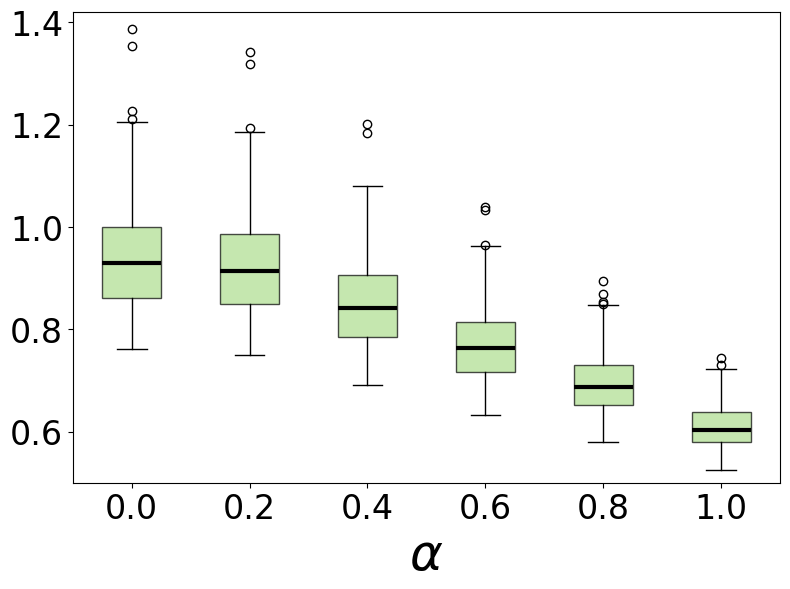

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4820\1895269226.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_set, labels=my_labels, patch_artist=True,


Plot saved as: .\Results_Case_Study\seed_12\Rawlsian_Price_EFO.pdf


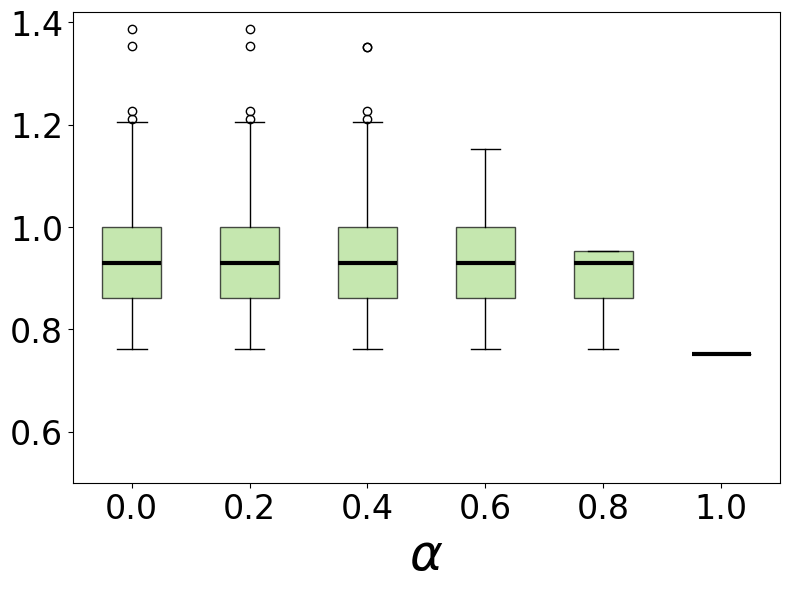

In [24]:
plt.close()
plot_default_boxplot(p_feo_test, y_limits=[0.5,1.42],filename=os.path.join(dir, f"Rawlsian_Price_FEO.pdf"))
plot_default_boxplot(p_list_test, y_limits=[0.5,1.42],filename=os.path.join(dir, f"Rawlsian_Price_EFO.pdf"))

In [25]:
wel_feo_test = [rev_feo_test[i] + sur_feo_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_feo_test)
sur_norm = normalize_to_percentage(sur_feo_test)
wel_norm = normalize_to_percentage(wel_feo_test)

# Organize data with English labels
data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

# Create DataFrame and Transpose to match the horizontal format
df = pd.DataFrame(data).set_index('α').T

# --- Display ---
print("Table: Normalized Performance Measures (%)") # English Caption
print("-" * 50)
print(df.round(2))
print("-" * 50)
target_alphas

Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0     0.2     0.4     0.6     0.8     1.0
R(α)/R(0)  100.0  100.01   99.27   97.02   93.39   87.48
S(α)/S(0)  100.0  101.88  113.06  126.25  139.70  155.82
W(α)/W(0)  100.0  100.84  105.44  110.11  114.12  118.07
--------------------------------------------------


[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

In [26]:
# --- Calculation ---
wel_list_test = [rev_list_test[i] + sur_list_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_list_test)
sur_norm = normalize_to_percentage(sur_list_test)
wel_norm = normalize_to_percentage(wel_list_test)

# Organize data with English labels
data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

# Create DataFrame and Transpose to match the horizontal format
df = pd.DataFrame(data).set_index('α').T

# --- Display ---
print("Table: Normalized Performance Measures (%)") # English Caption
print("-" * 50)
print(df.round(2))
print("-" * 50)

Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0    0.2     0.4     0.6     0.8     1.0
R(α)/R(0)  100.0  100.0  100.01  100.00   99.48   94.76
S(α)/S(0)  100.0  100.0  100.03  100.76  107.16  132.54
W(α)/W(0)  100.0  100.0  100.02  100.34  102.92  111.67
--------------------------------------------------


# Parity-wise Price Fairness

In [27]:
alpha_list = []

rev_feo_test, sur_feo_test = [], []

p0_feo_set, p1_feo_set = [], []

for alpha in np.linspace(0,1,6):
    def price_parity_1(params):
        a = params[:n_features]
        b = params[n_features:]
        p_star = opt_price(X, a, b, c)
        _p1 = np.mean(p_star[g])
        _p0 = np.mean(p_star[~g])
        return (1 - alpha) * price_gap - (_p1 - _p0)

    def price_parity_2(params):
        a = params[:n_features]
        b = params[n_features:]
        p_star = opt_price(X, a, b, c)
        _p1 = np.mean(p_star[g])
        _p0 = np.mean(p_star[~g])
        return (1 - alpha) * price_gap - (_p0 - _p1)

    x0 = np.concatenate([a_hat, np.array([b_hat])])

    constraints = [
        {'type': 'ineq', 'fun': constraint_b},
        {'type': 'ineq', 'fun': constraint_price_cap},
        {'type': 'ineq', 'fun': price_parity_1},
        {'type': 'ineq', 'fun': price_parity_2}
    ]

    result = minimize(
        fun=cross_entropy,
        x0=x0,
        method='SLSQP',
        constraints=constraints,
        options={'disp': False, 'maxiter': 5000} #, 'ftol':1e-9, 'eps':1e-8}
    )

    a_val = result.x[:n_features]
    b_val = result.x[-1]

    #####
    p_star_test = opt_price(X_test, a_val, b_val, c)
    p0_star_test, p1_star_test = np.mean(p_star_test[~g_test]), np.mean(p_star_test[g_test])

    _d, r, s = metrics(X_test, a_star, b_star, p_star_test, c)

    p0_feo_set.append(p_star_test[~g_test])
    p1_feo_set.append(p_star_test[g_test])

    rev_feo_test.append(r)
    sur_feo_test.append(s)
    
    alpha_list.append(alpha)

In [28]:
rev_list_test, sur_list_test = [], []

p0_efo_set = []
p1_efo_set = []

for alpha in alpha_list:
    def objective(p):
        p = np.asarray(p)
        _d = sigmoid(X_test @ a_hat + b_hat * p)
        r = np.dot(p-c, _d)
        return -np.sum(r)

    def constraint1_test(p):
        p0, p1 = np.mean(p[~g_test]), np.mean(p[g_test])
        return (1 - alpha) * price_gap - (p1 - p0)

    def constraint2_test(p):
        p0, p1 = np.mean(p[~g_test]), np.mean(p[g_test])
        return (1 - alpha) * price_gap - (p0 - p1)

    def constraint3(p):
        return p - c

    def constraint4(p):
        return price_cap - p

    x0 = np.ones(X_test.shape[0]) * c

    constraints = [
        {'type': 'ineq', 'fun': constraint1_test},
        {'type': 'ineq', 'fun': constraint2_test},
        {'type': 'ineq', 'fun': constraint3},
        {'type': 'ineq', 'fun': constraint4}
    ]

    result = minimize(
        fun=objective,
        x0=x0,
        method='SLSQP',
        constraints=constraints,
        options={'disp': False, 'maxiter': 5000}
    )

    p_star_test = result.x
    p0_efo_set.append(p_star_test[~g_test])
    p1_efo_set.append(p_star_test[g_test])

    _d, r_test, s_test = metrics(X_test, a_star, b_star, p_star_test, c)

    rev_list_test.append(r_test)
    sur_list_test.append(s_test)

    p_list_test.append(p_star_test)

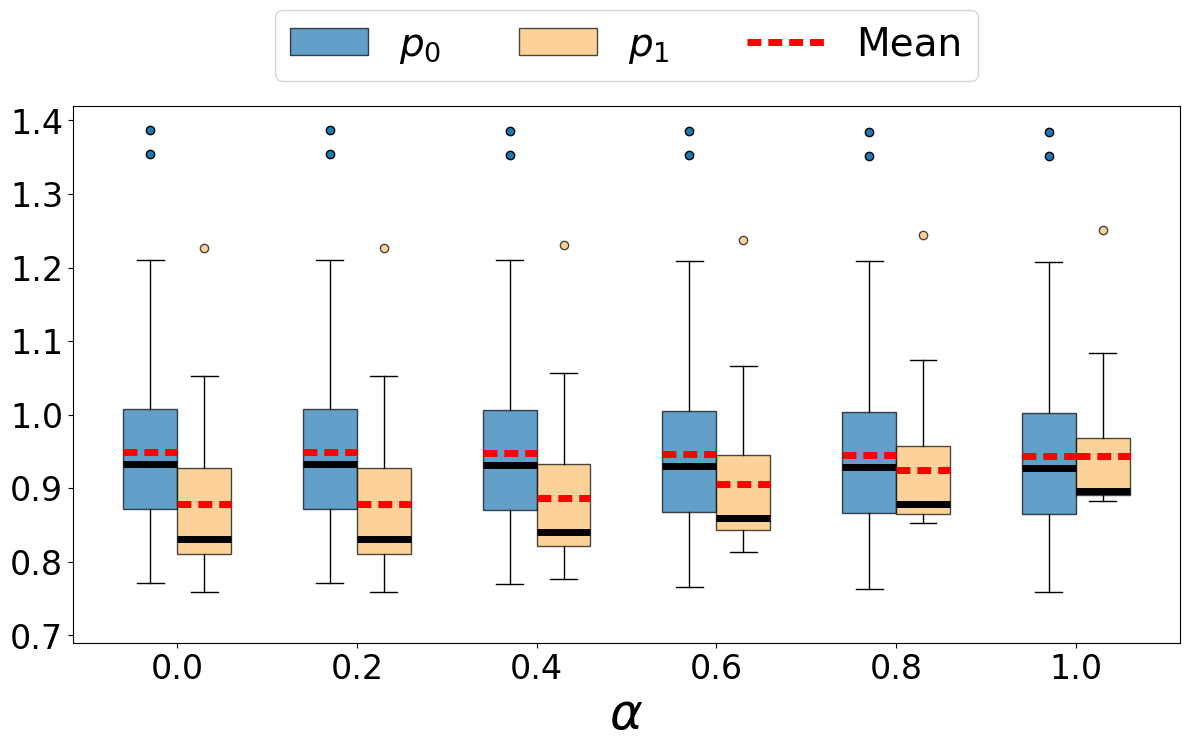

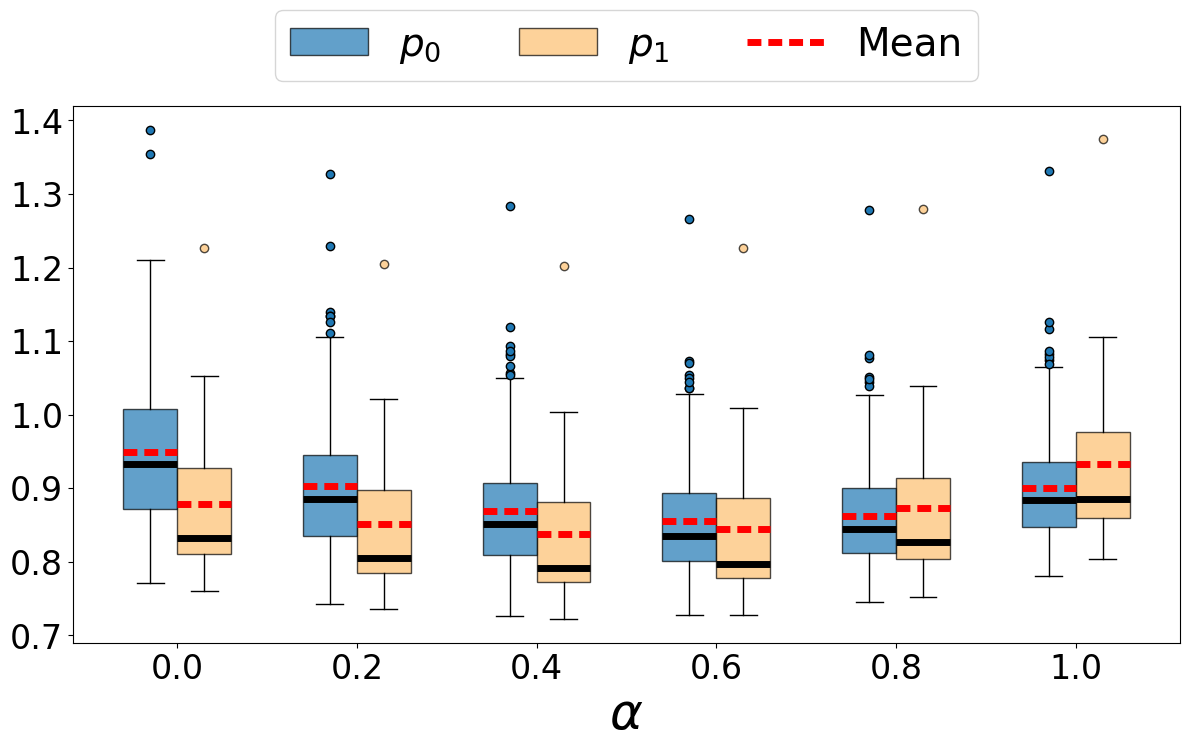

In [29]:
plot_grouped_boxplot(p0_efo_set, p1_efo_set,y_limits=[0.69,1.42], mean_plot=True, filename=os.path.join(dir, f"Parity_Price_Test_EFO.pdf"))
plot_grouped_boxplot(p0_feo_set, p1_feo_set,y_limits=[0.69,1.42], mean_plot=True, filename=os.path.join(dir, f"Parity_Price_Test_FEO.pdf"))

In [30]:
# --- Calculation ---
wel_feo_test = [rev_feo_test[i] + sur_feo_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_feo_test)
sur_norm = normalize_to_percentage(sur_feo_test)
wel_norm = normalize_to_percentage(wel_feo_test)

# Organize data with English labels
data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

# Create DataFrame and Transpose to match the horizontal format
df = pd.DataFrame(data).set_index('α').T

# --- Display ---
print("Table: Normalized Performance Measures (%)") # English Caption
print("-" * 50)
print(df.round(2))
print("-" * 50)

Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0     0.2     0.4     0.6     0.8     1.0
R(α)/R(0)  100.0   99.81   99.35   99.02   99.01   99.33
S(α)/S(0)  100.0  106.46  111.39  113.52  112.43  106.94
W(α)/W(0)  100.0  102.79  104.74  105.51  105.02  102.73
--------------------------------------------------


In [31]:
# --- Calculation ---
wel_list_test = [rev_list_test[i] + sur_list_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_list_test)
sur_norm = normalize_to_percentage(sur_list_test)
wel_norm = normalize_to_percentage(wel_list_test)

# Organize data with English labels
data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

# Create DataFrame and Transpose to match the horizontal format
df = pd.DataFrame(data).set_index('α').T

# --- Display ---
print("Table: Normalized Performance Measures (%)") # English Caption
print("-" * 50)
print(df.round(2))
print("-" * 50)

Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0    0.2    0.4    0.6    0.8    1.0
R(α)/R(0)  100.0  100.0  100.0  99.99  99.98  99.96
S(α)/S(0)  100.0  100.0  100.0  99.99  99.97  99.95
W(α)/W(0)  100.0  100.0  100.0  99.99  99.97  99.95
--------------------------------------------------


# Rawlsian Demand Fairness

In [32]:
beta_under_bar = min(d_hat)
beta_bar = min(sigmoid(X @ a_hat + b_hat * c))-0.01

In [33]:
from scipy.special import expit as sigmoid

rev_feo_test, sur_feo_test = [], []

d_feo_ex_ante = []
d_feo_ex_post = []  

beta_list = []

exponent = np.dot(X, a_hat) + b_hat * c - 1
lambert_value = lambertw(np.exp(exponent)).real
p_hat = (1 + lambert_value)/(-b_hat) + c
d_hat = sigmoid(X @ a_hat + b_hat * p_hat)

exponent = np.dot(X_test, a_hat) + b_hat * c - 1
lambert_value = lambertw(np.exp(exponent)).real
p_hat_test = (1 + lambert_value)/(-b_hat) + c
d_hat_test = sigmoid(X_test @ a_hat + b_hat * p_hat_test)

for beta in np.linspace(0,1,6):
    true_beta = (1-beta) * beta_under_bar + beta * beta_bar
    def constraint_rawls_demand(params):
        a = params[:n_features]
        b = params[n_features:]
        p_star = opt_price(X, a, b, c)
        return -1/b_hat * (np.log(1/true_beta-1) + X @ a_hat) - p_star

    x0 = np.concatenate([a_hat, np.array([b_hat])])

    constraints = [
        {'type': 'ineq', 'fun': constraint_b},
        {'type': 'ineq', 'fun': constraint_price_cap},
        {'type': 'ineq', 'fun': constraint_rawls_demand}
    ]

    result = minimize(
        fun=cross_entropy,
        x0=x0,
        method='SLSQP',
        constraints=constraints,
        options={'maxiter': 5000, 'disp': False}
    )

    a_val = result.x[:n_features]
    b_val = result.x[n_features:]

    ###
    p_star_test = opt_price(X_test, a_val, b_val, c)

    d_test, r_test, s_test = metrics(X_test, a_star, b_star, p_star_test, c)
    _d_test = sigmoid(X_test @ a_hat + b_hat * p_star_test)
    
    d_feo_ex_ante.append(_d_test)
    d_feo_ex_post.append(d_test)

    rev_feo_test.append(r_test)
    sur_feo_test.append(s_test)

    beta_list.append(beta)
    print('='*20)

In [34]:
rev_list_test, sur_list_test = [], []

d_efo_ex_ante = []
d_efo_ex_post = []

for beta in beta_list:
    true_beta = (1-beta) * beta_under_bar + beta * beta_bar

    d_star_test = np.maximum(d_hat_test, true_beta)
    d_efo_ex_ante.append(d_star_test)
    
    p_star_test = np.maximum(1/(-b_hat)*(np.log(1/d_star_test-1) + X_test @ a_hat),c)

    d_test, r_test, s_test = metrics(X_test, a_star, b_star, p_star_test, c)
    d_efo_ex_post.append(d_test)
    rev_list_test.append(r_test)
    sur_list_test.append(s_test)

In [35]:
print(beta_under_bar)
print(beta_bar)

0.08451713944939344
0.20582275927129706


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4820\1895269226.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_set, labels=my_labels, patch_artist=True,


Plot saved as: .\Results_Case_Study\seed_12\Rawlsian_ExAnte_Demand_FEO.pdf


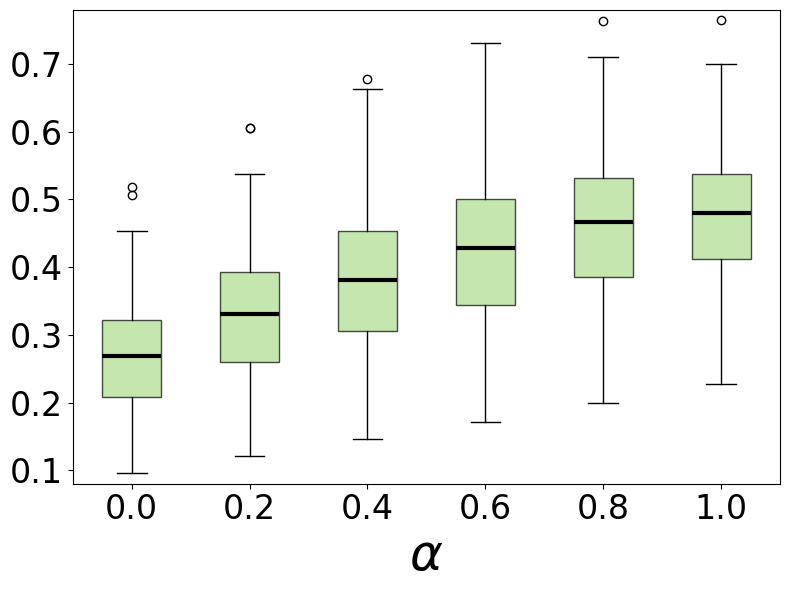

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4820\1895269226.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_set, labels=my_labels, patch_artist=True,


Plot saved as: .\Results_Case_Study\seed_12\Rawlsian_ExAnte_Demand_EFO.pdf


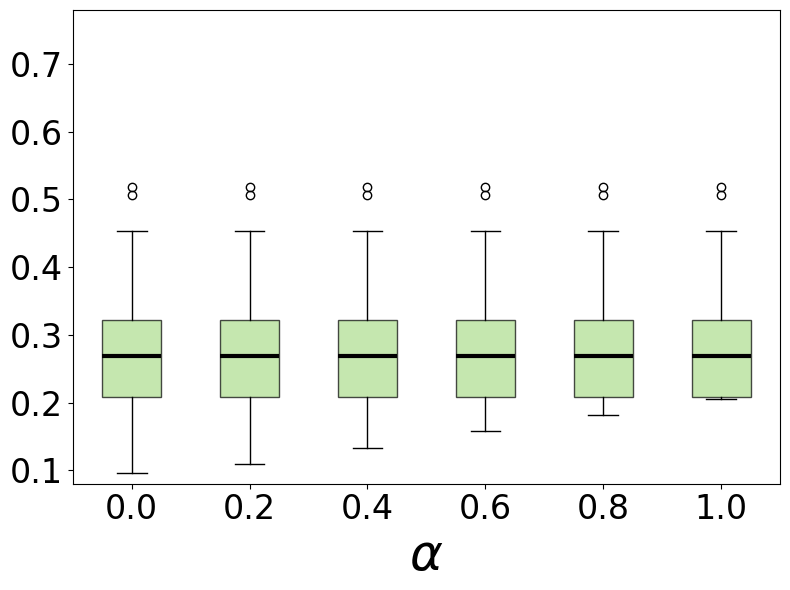

In [36]:
plot_default_boxplot(d_feo_ex_ante, y_limits=[0.08,0.78], filename=os.path.join(dir, f"Rawlsian_ExAnte_Demand_FEO.pdf"))
plot_default_boxplot(d_efo_ex_ante, y_limits=[0.08,0.78], filename=os.path.join(dir, f"Rawlsian_ExAnte_Demand_EFO.pdf"))

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4820\1895269226.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_set, labels=my_labels, patch_artist=True,


Plot saved as: .\Results_Case_Study\seed_12\Rawlsian_ExPost_Demand_FEO.pdf


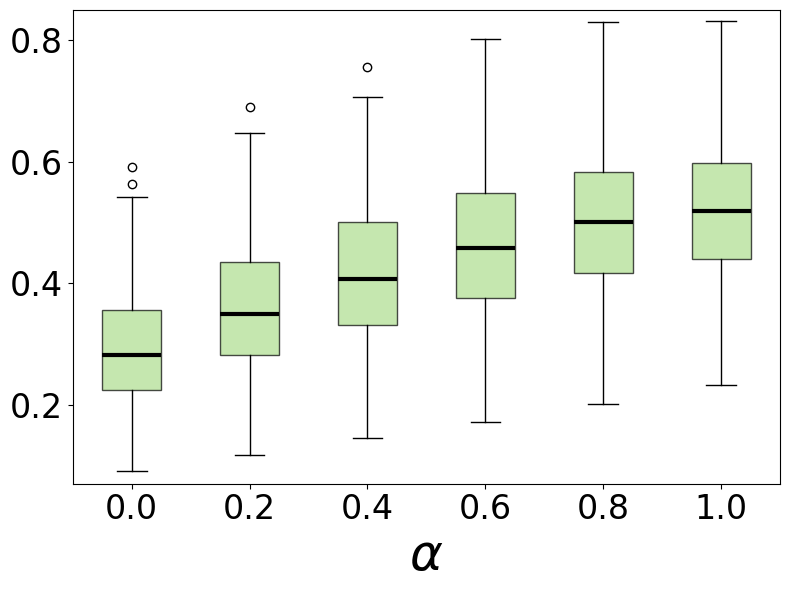

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4820\1895269226.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_set, labels=my_labels, patch_artist=True,


Plot saved as: .\Results_Case_Study\seed_12\Rawlsian_ExPost_Demand_EFO.pdf


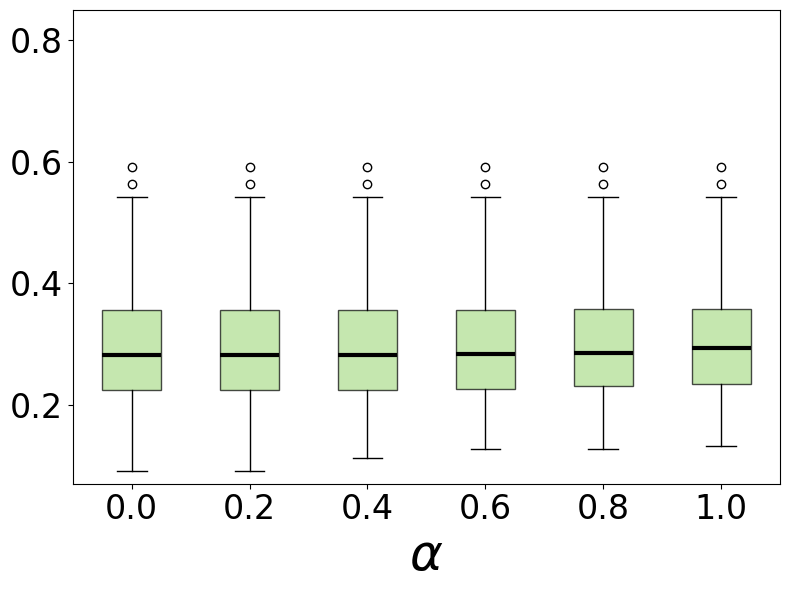

In [37]:
plot_default_boxplot(d_feo_ex_post, y_limits=[0.07,0.85],filename=os.path.join(dir, f"Rawlsian_ExPost_Demand_FEO.pdf"))
plot_default_boxplot(d_efo_ex_post, y_limits=[0.07,0.85],filename=os.path.join(dir, f"Rawlsian_ExPost_Demand_EFO.pdf"))

In [38]:
# --- Calculation ---
wel_feo_test = [rev_feo_test[i] + sur_feo_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_feo_test)
sur_norm = normalize_to_percentage(sur_feo_test)
wel_norm = normalize_to_percentage(wel_feo_test)

# Organize data with English labels
data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

# Create DataFrame and Transpose to match the horizontal format
df = pd.DataFrame(data).set_index('α').T

# --- Display ---
print("Table: Normalized Performance Measures (%)") # English Caption
print("-" * 50)
print(df.round(2))
print("-" * 50)

Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0     0.2     0.4     0.6     0.8     1.0
R(α)/R(0)  100.0   96.24   87.18   75.39   62.97   56.85
S(α)/S(0)  100.0  129.59  156.99  181.95  203.53  212.70
W(α)/W(0)  100.0  111.17  118.43  123.09  125.90  126.62
--------------------------------------------------


In [39]:
# --- Calculation ---
wel_list_test = [rev_list_test[i] + sur_list_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_list_test)
sur_norm = normalize_to_percentage(sur_list_test)
wel_norm = normalize_to_percentage(wel_list_test)

# Organize data with English labels
data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

# Create DataFrame and Transpose to match the horizontal format
df = pd.DataFrame(data).set_index('α').T

# --- Display ---
print("Table: Normalized Performance Measures (%)") # English Caption
print("-" * 50)
print(df.round(2))
print("-" * 50)


Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0     0.2     0.4     0.6     0.8     1.0
R(α)/R(0)  100.0   99.99   99.95   99.82   99.56   99.09
S(α)/S(0)  100.0  100.07  100.36  101.00  102.16  104.34
W(α)/W(0)  100.0  100.03  100.14  100.35  100.73  101.44
--------------------------------------------------


# Parity-wise Demand Fairness

In [40]:
alpha_list = []

epsilon = 1e-8

rev_feo_test, sur_feo_test = [], []

d0_feo_ex_ante, d1_feo_ex_ante = [], []
d0_feo_ex_post, d1_feo_ex_post = [], []

for alpha in np.linspace(0,1,6):
    def demand_parity_1(params):
        a = params[:n_features]
        b = params[n_features:]
        p_star = opt_price(X, a, b, c)
        d_star = sigmoid(X @ a_hat + b_hat * p_star)
        _d1 = np.mean(d_star[g])
        _d0 = np.mean(d_star[~g])
        return (1 - alpha) * demand_gap - (_d1 - _d0)

    def demand_parity_2(params):
        a = params[:n_features]
        b = params[n_features:]
        p_star = opt_price(X, a, b, c)
        d_star = sigmoid(X @ a_hat + b_hat * p_star)
        _d1 = np.mean(d_star[g])
        _d0 = np.mean(d_star[~g])
        return (1 - alpha) * demand_gap - (_d0 - _d1)

    x0 = np.concatenate([a_hat, np.array([b_hat])])

    constraints = [
        {'type': 'ineq', 'fun': constraint_b},
        {'type': 'ineq', 'fun': constraint_price_cap},
        {'type': 'ineq', 'fun': demand_parity_1},
        {'type': 'ineq', 'fun': demand_parity_2}
    ]

    result = minimize(
        fun=cross_entropy,
        x0=x0,
        method='SLSQP',
        constraints=constraints,
        options={'disp': False, 'maxiter': 5000} #, 'ftol':1e-9, 'eps':1e-8}
    )

    a_val = result.x[:n_features]
    b_val = result.x[n_features:]

    p_star = opt_price(X, a_val, b_val, c)
    p0_star, p1_star = np.mean(p_star[~g]), np.mean(p_star[g])

    _d, r, s = metrics(X, a_star, b_star, p_star, c)

    alpha_list.append(alpha)

    #####
    p_star_test = opt_price(X_test, a_val, b_val, c)

    d_test, r_test, s_test = metrics(X_test, a_star, b_star, p_star_test, c)
    _d_test = metrics(X_test, a_hat, b_hat, p_star_test, c)[0]
    
    d0_feo_ex_ante.append(_d_test[~g_test])
    d1_feo_ex_ante.append(_d_test[g_test])
    d0_feo_ex_post.append(d_test[~g_test])
    d1_feo_ex_post.append(d_test[g_test])

    rev_feo_test.append(r_test)
    sur_feo_test.append(s_test)

In [41]:
rev_list_test, sur_list_test = [], []

d0_efo_ex_ante, d1_efo_ex_ante = [], []
d0_efo_ex_post, d1_efo_ex_post = [], []

for alpha in alpha_list:
    def objective(p):
        p = np.asarray(p)
        _d = sigmoid(X_test @ a_hat + b_hat * p)
        r = np.dot(p-c, _d)
        return -np.sum(r)

    def constraint1_test(p):
        d = sigmoid(X_test @ a_hat + b_hat * p)
        d0, d1 = np.mean(d[~g_test]), np.mean(d[g_test])
        return (1 - alpha) * demand_gap - (d1 - d0)

    def constraint2_test(p):
        d = sigmoid(X_test @ a_hat + b_hat * p)
        d0, d1 = np.mean(d[~g_test]), np.mean(d[g_test])
        return (1 - alpha) * demand_gap - (d0 - d1)

    def constraint3(p):
        return p - c

    def constraint4(p):
        return price_cap - p

    x0 = np.ones(X_test.shape[0]) * c

    constraints = [
        {'type': 'ineq', 'fun': constraint1_test},
        {'type': 'ineq', 'fun': constraint2_test},
        {'type': 'ineq', 'fun': constraint3},
        {'type': 'ineq', 'fun': constraint4}
    ]

    result = minimize(
        fun=objective,
        x0=x0,
        method='SLSQP',
        constraints=constraints,
        options={'disp': False, 'maxiter': 5000}
    )

    p_star_test = result.x

    d_test, r_test, s_test = metrics(X_test, a_star, b_star, p_star_test, c)
    _d_test = metrics(X_test, a_hat, b_hat, p_star_test, c)[0]

    rev_list_test.append(r_test)
    sur_list_test.append(s_test)

    d0_efo_ex_ante.append(_d_test[~g_test])
    d1_efo_ex_ante.append(_d_test[g_test])
    d0_efo_ex_post.append(d_test[~g_test])
    d1_efo_ex_post.append(d_test[g_test])

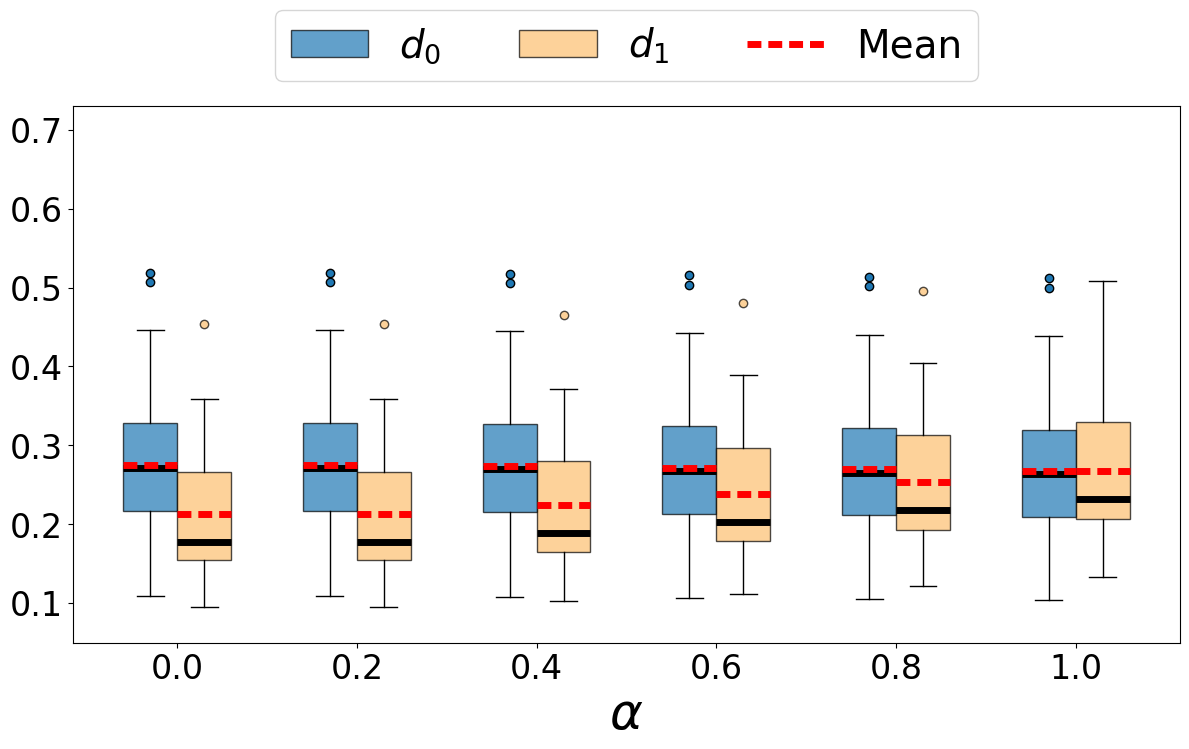

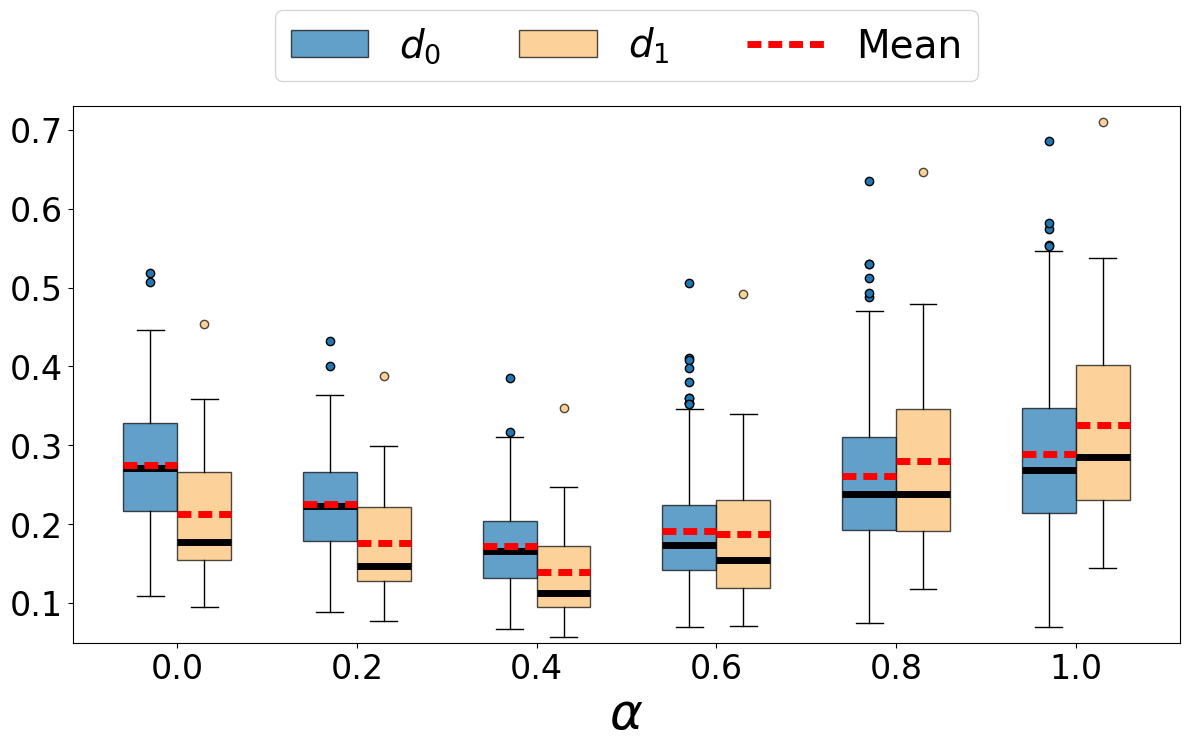

In [42]:
plot_grouped_boxplot(d0_efo_ex_ante, d1_efo_ex_ante, y_limits=[0.05,0.73],mean_plot=True, filename=os.path.join(dir, f"Parity_ExAnte_Demand_EFO.pdf"), price=False)
plot_grouped_boxplot(d0_feo_ex_ante, d1_feo_ex_ante, y_limits=[0.05,0.73],mean_plot=True, filename=os.path.join(dir, f"Parity_ExAnte_Demand_FEO.pdf"), price=False)

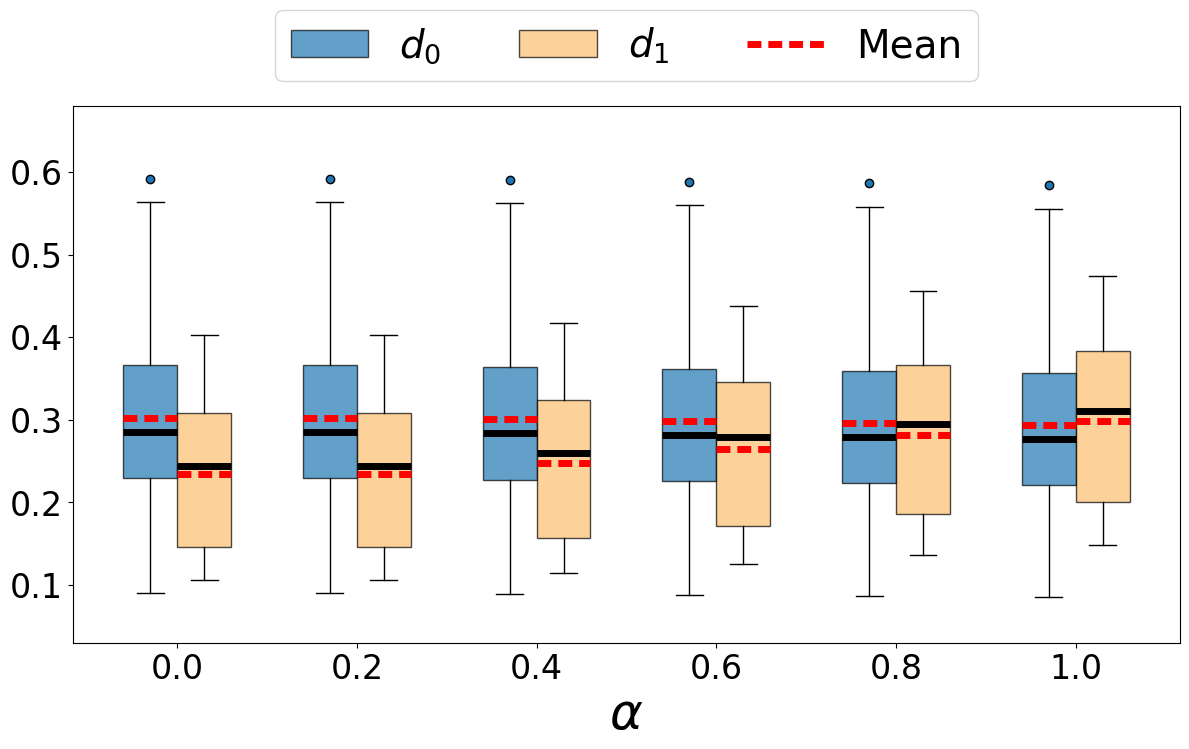

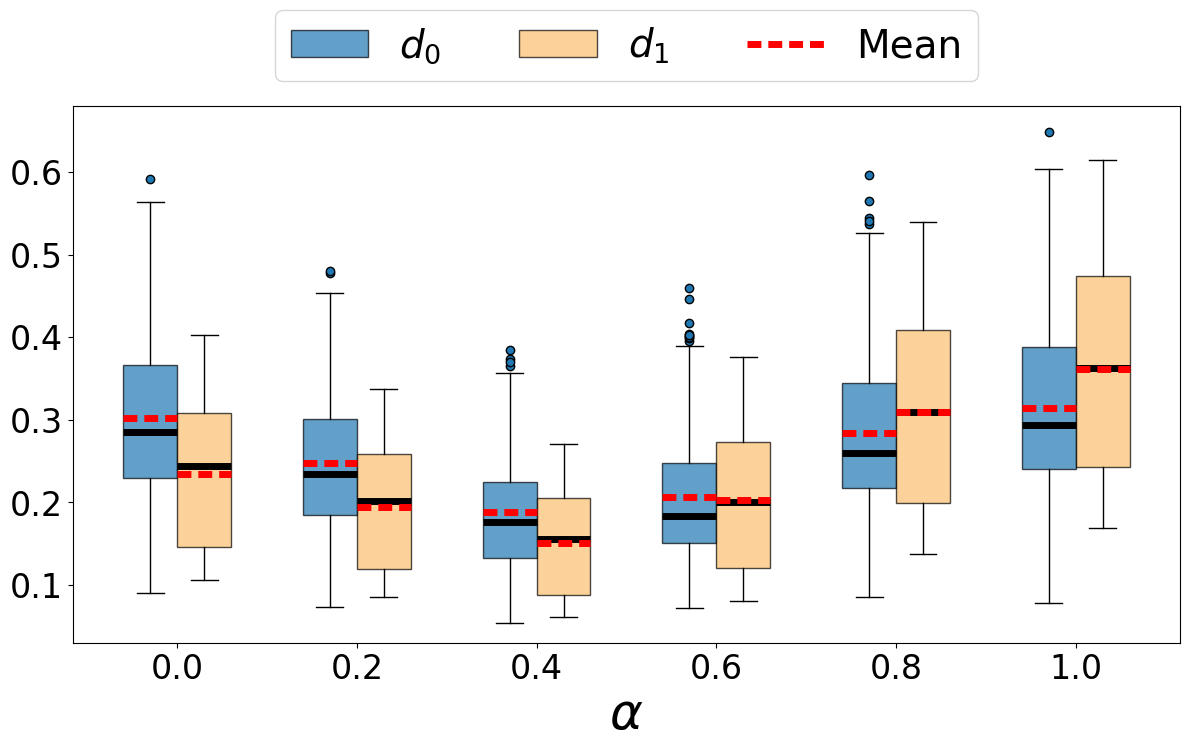

In [43]:
plot_grouped_boxplot(d0_efo_ex_post, d1_efo_ex_post, y_limits=[0.03,0.68],mean_plot=True, filename=os.path.join(dir, f"Parity_ExPost_Demand_EFO.pdf"), price=False)
plot_grouped_boxplot(d0_feo_ex_post, d1_feo_ex_post, y_limits=[0.03,0.68],mean_plot=True, filename=os.path.join(dir, f"Parity_ExPost_Demand_FEO.pdf"), price=False)

In [44]:
# --- Calculation ---
wel_feo_test = [rev_feo_test[i] + sur_feo_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_feo_test)
sur_norm = normalize_to_percentage(sur_feo_test)
wel_norm = normalize_to_percentage(wel_feo_test)

# --- Create Table ---
target_alphas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0] #[i/10 for i in range(1,11)] #
indices = [target_alphas.index(a) for a in target_alphas]

# Organize data with English labels
data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

# Create DataFrame and Transpose to match the horizontal format
df = pd.DataFrame(data).set_index('α').T

# --- Display ---
print("Table: Normalized Performance Measures (%)") # English Caption
print("-" * 50)
print(df.round(2))
print("-" * 50)


Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0    0.2    0.4    0.6    0.8     1.0
R(α)/R(0)  100.0  97.50  89.15  91.61  95.62   93.10
S(α)/S(0)  100.0  78.76  57.37  65.71  97.26  111.32
W(α)/W(0)  100.0  89.11  74.93  80.01  96.35  101.26
--------------------------------------------------


In [45]:
# --- Calculation ---
wel_list_test = [rev_list_test[i] + sur_list_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_list_test)
sur_norm = normalize_to_percentage(sur_list_test)
wel_norm = normalize_to_percentage(wel_list_test)

# Organize data with English labels
data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

# Create DataFrame and Transpose to match the horizontal format
df = pd.DataFrame(data).set_index('α').T

# --- Display ---
print("Table: Normalized Performance Measures (%)") # English Caption
print("-" * 50)
print(df.round(2))
print("-" * 50)


Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0    0.2    0.4    0.6    0.8    1.0
R(α)/R(0)  100.0  100.0  99.99  99.92  99.79  99.60
S(α)/S(0)  100.0  100.0  99.90  99.81  99.77  99.76
W(α)/W(0)  100.0  100.0  99.95  99.87  99.78  99.67
--------------------------------------------------
